# ðŸ““ Notebook 06 â€” AI Classification Engine

## Objective
Build a complete AI classification pipeline that predicts:

| Class | Label |
|-------|-------|
| Planet Transit | 0 |
| Eclipsing Binary | 1 |
| Background Blend | 2 |
| Stellar Variability / Noise | 3 |

---

## Research Progression

**Phase 1 (Current)** â€” Small dataset, manual labels â†’ Train AI â†’ Validate Pipeline

**Phase 2 (Future)** â€” Large TESS dataset, automatic TOI/TCE matching â†’ Retrain AI â†’ Research Results

Prove the methodology on a curated dataset first, then scale up.

## Notebook Structure

```
Part 1  â€” Setup, GPU, Configuration, Load Features, Load Labels
Part 2  â€” Dataset Preparation (Encoding, Scaling, Train/Test Split)
Part 3  â€” Classical ML Baseline (Random Forest)
Part 4  â€” Deep Neural Network (MLP with PyTorch)
Part 5  â€” Evaluation (Classification Report, Confusion Matrix, ROC)
Part 6  â€” Save Everything (Models, Reports, Figures)
```

---

## Why start with a baseline model?

Even if the end goal is a neural network, a baseline model (Random Forest) helps answer:
* Are the engineered features actually informative?
* Is there a problem with the labels?
* Is the dataset balanced?
* What level of performance is achievable before introducing a more complex model?

---

## Neural Network Architecture

A fully connected MLP for tabular features (~60 features):

```
Input Layer â†’ Dense(256) â†’ BatchNorm â†’ ReLU â†’ Dropout(0.30)
    â†’ Dense(128) â†’ BatchNorm â†’ ReLU â†’ Dropout(0.25)
    â†’ Dense(64) â†’ ReLU â†’ Dense(32) â†’ Softmax (4 Classes)
```

---

## Output Folder Structure

```
models/
  best_model.pth      (best PyTorch model weights)
  random_forest.pkl   (trained Random Forest)
  scaler.pkl          (fitted StandardScaler)
  label_encoder.pkl   (LabelEncoder)

reports/
  classification_report.txt
  confusion_matrix.csv
  training_history.csv
  feature_importance.csv

figures/
  confusion_matrix.png
  roc_curve.png
  loss_curve.png
  accuracy_curve.png
```

# Part 1  Setup, GPU, Configuration, Load Features, Load Labels

In [32]:
import os
import gc
import json
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
print("Libraries imported")

Libraries imported


In [33]:
# GPU Detection
GPU_AVAILABLE = False
GPU_NAME = "None"
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    if GPU_AVAILABLE:
        GPU_NAME = torch.cuda.get_device_name(0)
        print(f"GPU detected: {GPU_NAME}")
    else:
        print("No GPU detected, using CPU")
except ImportError:
    print("PyTorch not installed, will use CPU")

DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")

GPU detected: NVIDIA GeForce RTX 3050 Laptop GPU


In [34]:
PROJECT_NAME = "Exoplanet-detection"
ROOT_DIR = Path("D:/MachineLearning") / PROJECT_NAME

LIGHTCURVE_DIR = ROOT_DIR / "data" / "processed" / "lightcurves"
CANDIDATE_DIR = ROOT_DIR / "data" / "processed" / "candidates"
FEATURE_DIR = ROOT_DIR / "data" / "processed" / "features"
MODEL_DIR = ROOT_DIR / "models"
REPORT_DIR = ROOT_DIR / "reports"
FIGURE_DIR = ROOT_DIR / "figures"
LOG_DIR = ROOT_DIR / "logs"

for _dir in [MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "notebook_06.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="w"),
        logging.StreamHandler()
    ],
    force=True
)
logger = logging.getLogger("Notebook06")
logger.info("Notebook 06 Started")

print(f"Configuration loaded - {len(list(LIGHTCURVE_DIR.glob('*.parquet')))} lightcurves available")

2026-07-27 21:38:22,312 | INFO | Notebook 06 Started


Configuration loaded - 89 lightcurves available


In [35]:
# Load candidate catalog
candidate_path = CANDIDATE_DIR / "candidate_catalog.parquet"
catalog = pd.read_parquet(candidate_path)
logger.info(f"Candidate catalog loaded: {len(catalog)} candidates")
catalog.head()

2026-07-27 21:38:22,356 | INFO | Candidate catalog loaded: 89 candidates


,tic_id,sector,source_file,period,duration,depth,epoch,sde,transit_snr,bls_power,distinct_transit_count,detector,confidence_score,quality_flag,rms,photometric_snr,num_points,estimated_transit_depth
0,100990000,3,TIC_100990000_Sector_3.parquet,9.581046,0.088920,0.999720,1386.184858,9.485989,8.836415,NaN,2,TLS,0.408613,REVIEW,0.000316,3167.188593,13532,0.001210
1,120252452,40,TIC_120252452_Sector_40.parquet,7.136761,0.039792,0.995005,2392.173341,6.523080,5.057516,NaN,4,TLS,0.316497,REJECT,0.008784,113.838699,19611,0.034610
2,120422519,53,TIC_120422519_Sector_53.parquet,6.957944,0.060194,0.993955,2746.613965,4.383445,4.529865,NaN,4,TLS,0.257778,REJECT,0.014823,67.462511,16991,0.062193
3,120691237,80,TIC_120691237_Sector_80.parquet,4.807281,0.032424,0.991279,3482.272404,4.895779,4.635307,NaN,6,TLS,0.291490,REJECT,0.018543,53.927798,17255,0.083770
4,121395761,40,TIC_121395761_Sector_40.parquet,7.075744,0.093817,0.992625,2390.960286,4.909971,4.760164,NaN,3,TLS,0.253902,REJECT,0.019285,51.853578,19609,0.079758


### Load or Create Labels

The pipeline expects a label CSV with columns: `tic_id`, `label` (int), `class_name` (str).

**Option A:** Load from manual label file (recommended for Phase 1).

**Option B:** Auto-generate from master catalog (all planets â†’ class 0).

Switch by changing which file is loaded below.

In [36]:
LABEL_FILE = ROOT_DIR / "data" / "raw" / "manual_labels.csv"

if LABEL_FILE.exists():
    labels = pd.read_csv(LABEL_FILE)
    logger.info(f"Loaded manual labels from {LABEL_FILE}: {len(labels)} rows")
else:
    logger.warning(f"{LABEL_FILE} not found. Creating default labels from master catalog.")
    master_cat = pd.read_parquet(ROOT_DIR / "data" / "processed" / "master_catalog.parquet")
    ids_in_catalog = catalog["tic_id"].unique()
    labels = master_cat[master_cat["tic_id"].isin(ids_in_catalog)][["tic_id"]].copy()
    labels["label"] = 0
    labels["class_name"] = "Planet"
    logger.info(f"Default labels created: {len(labels)} rows (all class 0 - Planet)")

labels.head()

2026-07-27 21:38:22,401 | INFO | Loaded manual labels from D:\MachineLearning\Exoplanet-detection\data\raw\manual_labels.csv: 89 rows


,tic_id,label,class_name
0,26961231,3,Stellar Variability
1,27011135,2,Background Blend
2,27318774,0,Planet
3,27390527,3,Stellar Variability
4,27843776,3,Stellar Variability


### Feature Engineering from Processed Light Curves

Since Notebook 05 did not persist features to disk, we compute them here.
Each light curve produces statistical, temporal, and frequency features,
merged with transit parameters from the candidate catalog.

In [37]:
def compute_statistical_features(flux):
    f = flux[~np.isnan(flux)]
    if len(f) == 0:
        return {}
    return {
        "mean_flux": float(np.mean(f)),
        "median_flux": float(np.median(f)),
        "std_flux": float(np.std(f)),
        "variance": float(np.var(f)),
        "minimum_flux": float(np.min(f)),
        "maximum_flux": float(np.max(f)),
        "dynamic_range": float(np.max(f) - np.min(f)),
        "rms": float(np.sqrt(np.mean(f ** 2))),
        "mad": float(np.median(np.abs(f - np.median(f)))),
        "skewness": float(pd.Series(f).skew()),
        "kurtosis": float(pd.Series(f).kurtosis()),
        "percentile_5": float(np.percentile(f, 5)),
        "percentile_25": float(np.percentile(f, 25)),
        "percentile_75": float(np.percentile(f, 75)),
        "percentile_95": float(np.percentile(f, 95)),
        "iqr": float(np.percentile(f, 75) - np.percentile(f, 25)),
        "flux_entropy": float(-np.sum((f / f.sum()) * np.log(f / f.sum() + 1e-12))),
        "zero_crossings": int(np.sum(np.diff(np.sign(f - np.median(f))) != 0)),
    }


def compute_temporal_features(time):
    t = time[~np.isnan(time)]
    if len(t) < 2:
        return {}
    diffs = np.diff(t)
    time_span = t[-1] - t[0]
    return {
        "observation_duration_days": float(time_span),
        "num_observations": int(len(t)),
        "median_cadence_days": float(np.median(diffs)),
        "mean_cadence_days": float(np.mean(diffs)),
        "std_cadence_days": float(np.std(diffs)),
        "cadence_minutes": float(np.median(diffs) * 1440),
        "largest_gap_days": float(np.max(diffs)),
        "mean_gap_days": float(np.mean(diffs)),
        "gap_fraction": float(np.sum(diffs[diffs > 1.5 * np.median(diffs)]) / time_span) if time_span > 0 else 0,
        "sampling_density": float(len(t) / time_span) if time_span > 0 else 0,
        "time_span_hours": float(time_span * 24),
    }


def compute_frequency_features(flux, time):
    f = flux[~np.isnan(flux)]
    if len(f) < 10:
        return {}
    f_detrend = f - np.mean(f)
    n = len(f_detrend)
    fft = np.fft.rfft(f_detrend * np.hanning(n))
    power = np.abs(fft) ** 2
    freqs = np.fft.rfftfreq(n, d=np.nanmedian(np.diff(time)))
    freqs = freqs[1:]
    power = power[1:]
    if len(power) == 0:
        return {}
    idx_sorted = np.argsort(power)[::-1]
    top_idx = idx_sorted[:3]
    p_sum = power.sum()
    p_norm = power / p_sum if p_sum > 0 else power
    entropy = -np.sum(p_norm * np.log(p_norm + 1e-12))
    return {
        "dominant_frequency": float(freqs[top_idx[0]]),
        "dominant_period": float(1.0 / freqs[top_idx[0]]) if freqs[top_idx[0]] > 0 else 0,
        "dominant_power": float(power[top_idx[0]]),
        "second_frequency": float(freqs[top_idx[1]]) if len(top_idx) > 1 else 0,
        "second_power": float(power[top_idx[1]]) if len(top_idx) > 1 else 0,
        "third_frequency": float(freqs[top_idx[2]]) if len(top_idx) > 2 else 0,
        "third_power": float(power[top_idx[2]]) if len(top_idx) > 2 else 0,
        "mean_spectral_power": float(np.mean(power)),
        "max_spectral_power": float(np.max(power)),
        "spectral_std": float(np.std(power)),
        "spectral_entropy": float(entropy),
        "spectral_energy": float(np.sum(power)),
        "harmonic_ratio": float(power[top_idx[0]] / power[top_idx[1]]) if len(top_idx) > 1 and power[top_idx[1]] > 0 else 0,
        "power_concentration": float(np.sum(power[:max(5, len(power)//10)]) / p_sum) if p_sum > 0 else 0,
        "frequency_variance": float(np.var(power)),
    }


def extract_features_for_target(tic_id, df_lc, candidate_info):
    flux = df_lc["flux"].values
    time = df_lc["time"].values
    features = {"tic_id": tic_id}
    features.update(compute_statistical_features(flux))
    features.update(compute_temporal_features(time))
    features.update(compute_frequency_features(flux, time))
    if candidate_info is not None:
        for col in ["period", "duration", "depth", "epoch", "sde", "transit_snr"]:
            if col in candidate_info:
                features[f"transit_{col}"] = candidate_info[col]
    return features


print("Feature extraction functions defined")

Feature extraction functions defined


In [38]:
# Build full feature matrix
tic_ids = catalog["tic_id"].unique()
candidate_map = catalog.set_index("tic_id").to_dict(orient="index")

all_features = []
for tic_id in tqdm(tic_ids, desc="Extracting features"):
    lc_files = sorted(LIGHTCURVE_DIR.glob(f"TIC_{tic_id}_*.parquet"))
    if not lc_files:
        logger.warning(f"No lightcurve file for TIC {tic_id}")
        continue
    df_lc = pd.read_parquet(lc_files[0])
    candidate_info = candidate_map.get(tic_id, None)
    feats = extract_features_for_target(tic_id, df_lc, candidate_info)
    all_features.append(feats)

feature_df = pd.DataFrame(all_features)
logger.info(f"Feature matrix: {feature_df.shape[0]} samples x {feature_df.shape[1]} features")
feature_df.head()

Extracting features:   0%|          | 0/89 [00:00<?, ?it/s]

2026-07-27 21:38:24,139 | INFO | Feature matrix: 89 samples x 51 features


,tic_id,mean_flux,median_flux,std_flux,variance,minimum_flux,maximum_flux,dynamic_range,rms,mad,...,spectral_energy,harmonic_ratio,power_concentration,frequency_variance,transit_period,transit_duration,transit_depth,transit_epoch,transit_sde,transit_transit_snr
0,100990000,1.000003,1.0,0.000316,9.969013e-08,0.998790,1.001490,0.002700,1.000003,0.000210,...,3.437334,1.249140,0.117639,2.599556e-07,9.581046,0.088920,0.999720,1386.184858,9.485989,8.836415
1,120252452,1.000077,1.0,0.008784,7.716496e-05,0.965390,1.035600,0.070210,1.000115,0.005844,...,5371.123425,1.161232,0.105499,3.028807e-01,7.136761,0.039792,0.995005,2392.173341,6.523080,5.057516
2,120422519,0.999908,1.0,0.014823,2.197227e-04,0.937807,1.056137,0.118330,1.000018,0.009901,...,11968.569418,1.005991,0.096381,1.934120e+00,6.957944,0.060194,0.993955,2746.613965,4.383445,4.529865
3,120691237,0.999880,1.0,0.018543,3.438544e-04,0.916230,1.075800,0.159570,1.000052,0.012093,...,17744.171570,1.146112,0.109719,4.341236e+00,4.807281,0.032424,0.991279,3482.272404,4.895779,4.635307
4,121395761,0.999922,1.0,0.019285,3.719140e-04,0.920242,1.085775,0.165533,1.000108,0.012894,...,25652.678757,1.518062,0.109509,7.056399e+00,7.075744,0.093817,0.992625,2390.960286,4.909971,4.760164


In [39]:
# Merge with labels
data = feature_df.merge(labels, on="tic_id", how="inner")
logger.info(f"Merged data: {data.shape[0]} samples, {data.shape[1]} columns")
print(f"Class distribution:\n{data['class_name'].value_counts()}")

2026-07-27 21:38:24,188 | INFO | Merged data: 89 samples, 53 columns


Class distribution:
class_name
Stellar Variability    23
Planet                 22
Eclipsing Binary       22
Background Blend       22
Name: count, dtype: int64


# Part 2  Dataset Preparation

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle

# Separate features, labels, identifiers
id_cols = ["tic_id", "label", "class_name"]
feature_cols = [c for c in data.columns if c not in id_cols]

X = data[feature_cols].copy()
y = data["label"].values

# Handle remaining NaNs
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    logger.info(f"Filling NaNs in columns: {nan_cols}")
    X[nan_cols] = X[nan_cols].fillna(0)

# Encode labels (in case they are strings)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = [str(c) for c in label_encoder.classes_]
num_classes = len(class_names)
logger.info(f"Classes: {class_names}, num_classes={num_classes}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
logger.info(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logger.info(f"Features scaled: {X_train_scaled.shape[1]} features")

2026-07-27 21:38:24,245 | INFO | Classes: ['0', '1', '2', '3'], num_classes=4
2026-07-27 21:38:24,249 | INFO | Train: 71, Test: 18
2026-07-27 21:38:24,263 | INFO | Features scaled: 50 features


# Part 3 Classical ML Baseline (Random Forest)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=min(15, len(feature_cols)),
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")
logger.info(f"Random Forest - Accuracy: {acc_rf:.4f}, F1 (weighted): {f1_rf:.4f}")
print(f"Random Forest Test Accuracy: {acc_rf:.4f}")
print(f"Random Forest F1 (weighted): {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=class_names))

2026-07-27 21:38:25,628 | INFO | Random Forest - Accuracy: 0.6111, F1 (weighted): 0.6177


Random Forest Test Accuracy: 0.6111
Random Forest F1 (weighted): 0.6177

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.67      0.50      0.57         4
           2       0.43      0.60      0.50         5
           3       0.75      0.60      0.67         5

    accuracy                           0.61        18
   macro avg       0.65      0.61      0.62        18
weighted avg       0.64      0.61      0.62        18



In [42]:
# Feature importance from Random Forest
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 most important features:")
importance.head(15)

Top 15 most important features:


,feature,importance
48,transit_sde,0.194764
49,transit_transit_snr,0.107245
32,second_frequency,0.039014
42,power_concentration,0.038765
10,kurtosis,0.031374
34,third_frequency,0.030259
45,transit_duration,0.029418
41,harmonic_ratio,0.022678
30,dominant_period,0.021445
9,skewness,0.021361


# Part 4 Deep Neural Network (MLP)

Architecture:
```
Input  Dense(256) , BatchNorm , ReLU , Dropout(0.30)
      Dense(128) , BatchNorm , ReLU , Dropout(0.25)
      Dense(64) , ReLU â†’ Dense(32) , Softmax (4 Classes)
```

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class LabelSmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, pred, target):
        n_classes = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_labels = one_hot * (1 - self.smoothing) + self.smoothing / n_classes
        log_probs = torch.log_softmax(pred, dim=1)
        return -(smooth_labels * log_probs).sum(dim=1).mean()

class TransitClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(96, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(24, num_classes),
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train_scaled.shape[1]
model = TransitClassifier(input_dim, num_classes).to(DEVICE)
criterion = LabelSmoothCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

print(f"Model created - input_dim={input_dim}, num_classes={num_classes}, device={DEVICE}")
print(model)


Model created - input_dim=50, num_classes=4, device=cuda
TransitClassifier(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=32, bias=True)
    (11): ReLU()
    (12): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [44]:
BATCH_SIZE = 64
EPOCHS = 300

train_tensor = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.LongTensor(y_train)
)
test_tensor = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.LongTensor(y_test)
)

train_loader = DataLoader(train_tensor, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_tensor, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created - train: {len(train_loader)} batches, test: {len(test_loader)} batches")


DataLoaders created - train: 5 batches, test: 2 batches


In [45]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return total_loss / len(loader), 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return total_loss / len(loader), 100.0 * correct / total


print("Training functions defined")

Training functions defined


In [46]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_test_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    train_loss = total_loss / len(train_loader)
    train_acc = 100.0 * correct / total

    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    test_loss = test_loss / len(test_loader)
    test_acc = 100.0 * correct / total
    scheduler.step(epoch)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), MODEL_DIR / "best_model.pth")

    if epoch % 50 == 0 or epoch == 1:
        logger.info(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} (Acc: {train_acc:.2f}%) | Test Loss: {test_loss:.4f} (Acc: {test_acc:.2f}%)")

logger.info(f"Training complete. Best test accuracy: {best_test_acc:.2f}%")


Training:   0%|          | 0/200 [00:00<?, ?it/s]

2026-07-27 21:38:25,951 | INFO | Epoch   1 | Train Loss: 1.3902 (Acc: 25.35%) | Test Loss: 1.4077 (Acc: 27.78%)
2026-07-27 21:38:27,287 | INFO | Epoch  25 | Train Loss: 0.5643 (Acc: 84.51%) | Test Loss: 1.9307 (Acc: 50.00%)
2026-07-27 21:38:28,544 | INFO | Epoch  50 | Train Loss: 0.5030 (Acc: 87.32%) | Test Loss: 2.0679 (Acc: 44.44%)
2026-07-27 21:38:29,611 | INFO | Epoch  75 | Train Loss: 0.3874 (Acc: 90.14%) | Test Loss: 2.2269 (Acc: 44.44%)
2026-07-27 21:38:30,704 | INFO | Epoch 100 | Train Loss: 0.4110 (Acc: 87.32%) | Test Loss: 2.2302 (Acc: 44.44%)
2026-07-27 21:38:31,771 | INFO | Epoch 125 | Train Loss: 0.4560 (Acc: 87.32%) | Test Loss: 2.2449 (Acc: 44.44%)
2026-07-27 21:38:32,888 | INFO | Epoch 150 | Train Loss: 0.4546 (Acc: 84.51%) | Test Loss: 2.2266 (Acc: 44.44%)
2026-07-27 21:38:33,929 | INFO | Epoch 175 | Train Loss: 0.3853 (Acc: 85.92%) | Test Loss: 2.2364 (Acc: 44.44%)
2026-07-27 21:38:35,048 | INFO | Epoch 200 | Train Loss: 0.4635 (Acc: 85.92%) | Test Loss: 2.2165 (Acc: 

# Part 5 Evaluation

In [47]:
# Evaluate best model on test set
model.load_state_dict(torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE, weights_only=True))
model.eval()

with torch.no_grad():
    inputs = torch.FloatTensor(X_test_scaled).to(DEVICE)
    outputs = model(inputs)
    y_prob_nn = torch.softmax(outputs, dim=1).cpu().numpy()
    y_pred_nn = outputs.argmax(dim=1).cpu().numpy()

acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn, average="weighted")
logger.info(f"Neural Network - Accuracy: {acc_nn:.4f}, F1 (weighted): {f1_nn:.4f}")

print("=" * 60)
print("  NEURAL NETWORK TEST RESULTS")
print("=" * 60)
print(f"Accuracy:  {acc_nn:.4f}")
print(f"F1 (weighted): {f1_nn:.4f}")
print()
print(classification_report(y_test, y_pred_nn, target_names=class_names))

2026-07-27 21:38:35,142 | INFO | Neural Network - Accuracy: 0.5556, F1 (weighted): 0.5501


  NEURAL NETWORK TEST RESULTS
Accuracy:  0.5556
F1 (weighted): 0.5501

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4
           2       0.50      0.60      0.55         5
           3       0.50      0.40      0.44         5

    accuracy                           0.56        18
   macro avg       0.57      0.56      0.56        18
weighted avg       0.56      0.56      0.55        18



In [48]:
# Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix (Neural Network):")
print(pd.DataFrame(cm_nn, index=class_names, columns=class_names))
print()
print("Confusion Matrix (Random Forest):")
print(pd.DataFrame(cm_rf, index=class_names, columns=class_names))

Confusion Matrix (Neural Network):
   0  1  2  3
0  3  0  1  0
1  1  2  1  0
2  0  0  3  2
3  1  1  1  2

Confusion Matrix (Random Forest):
   0  1  2  3
0  3  0  1  0
1  1  2  1  0
2  0  1  3  1
3  0  0  2  3


In [49]:
# Save reports
report_nn = classification_report(y_test, y_pred_nn, target_names=class_names, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=class_names, output_dict=True)

with open(REPORT_DIR / "classification_report.txt", "w") as f:
    f.write("=" * 60 + "\n")
    f.write("  NEURAL NETWORK CLASSIFICATION REPORT\n")
    f.write("=" * 60 + "\n")
    f.write(classification_report(y_test, y_pred_nn, target_names=class_names))
    f.write("\n" + "=" * 60 + "\n")
    f.write("  RANDOM FOREST CLASSIFICATION REPORT\n")
    f.write("=" * 60 + "\n")
    f.write(classification_report(y_test, y_pred_rf, target_names=class_names))

pd.DataFrame(cm_nn, index=class_names, columns=class_names).to_csv(
    REPORT_DIR / "confusion_matrix.csv"
)
pd.DataFrame(history).to_csv(REPORT_DIR / "training_history.csv", index=False)
importance.to_csv(REPORT_DIR / "feature_importance.csv", index=False)

logger.info("Reports saved")
print("Reports saved to reports/")

2026-07-27 21:38:35,365 | INFO | Reports saved


Reports saved to reports/


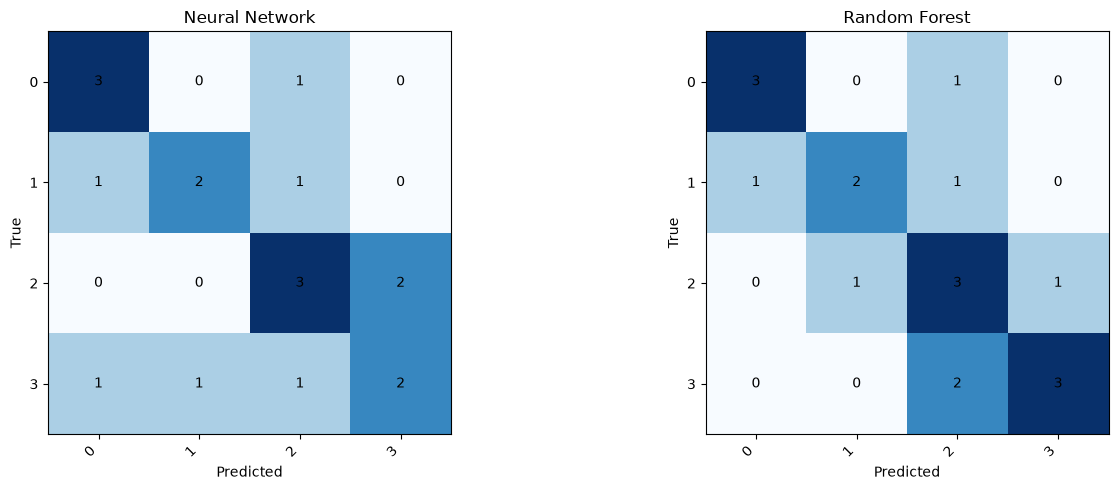

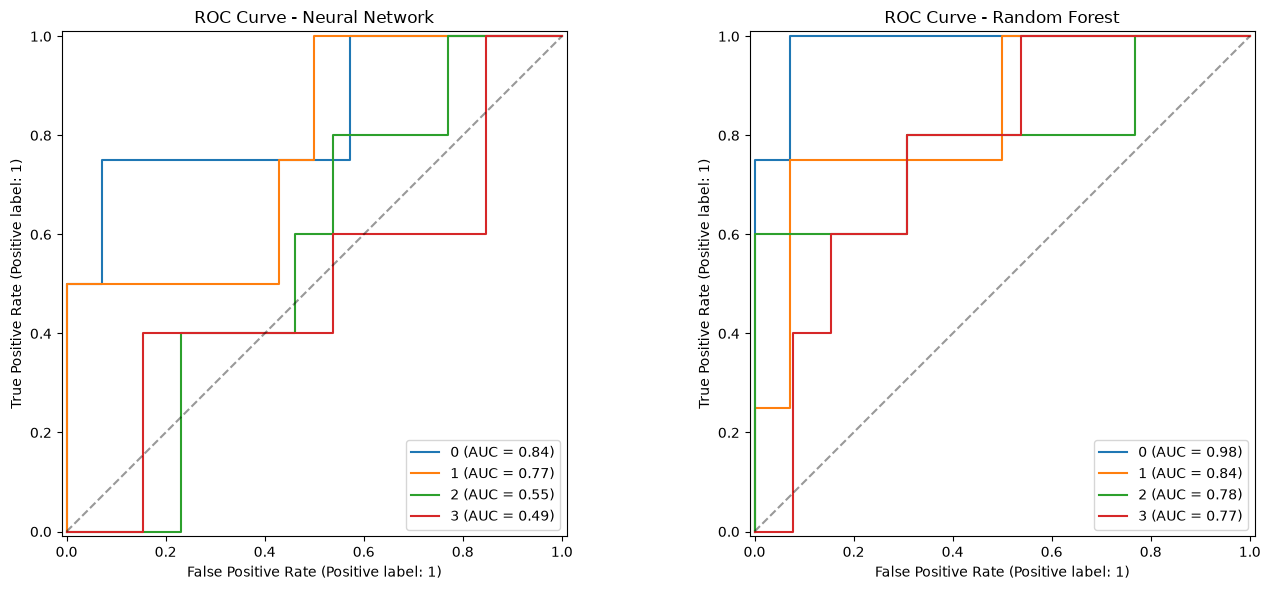

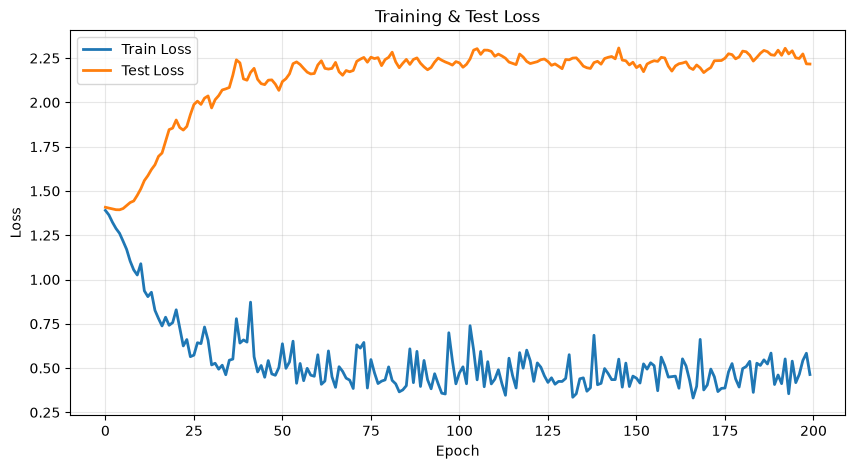

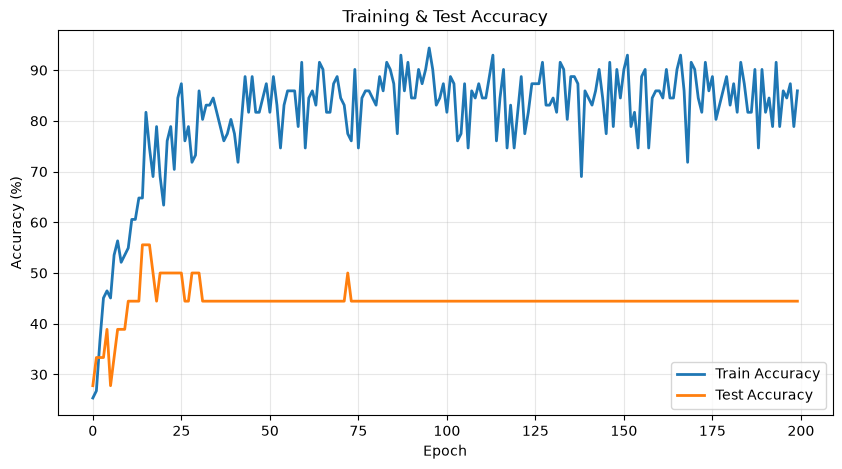

2026-07-27 21:38:38,424 | INFO | All figures saved


Figures saved to figures/


In [50]:
# Figures
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# 1. Confusion Matrix Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(axes, [cm_nn, cm_rf], ["Neural Network", "Random Forest"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. ROC Curves (one-vs-rest)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_prob, title in zip(axes, [y_prob_nn, y_prob_rf], ["Neural Network", "Random Forest"]):
    for i in range(num_classes):
        RocCurveDisplay.from_predictions(
            y_test == i, y_prob[:, i], ax=ax, name=class_names[i]
        )
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"ROC Curve - {title}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Loss Curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["train_loss"], label="Train Loss", lw=2)
ax.plot(history["test_loss"], label="Test Loss", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Test Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Accuracy Curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["train_acc"], label="Train Accuracy", lw=2)
ax.plot(history["test_acc"], label="Test Accuracy", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Training & Test Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info("All figures saved")
print("Figures saved to figures/")

# Part 6  Save Everything

In [ ]:
# Save trained models
with open(MODEL_DIR / "random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)
    

with open(MODEL_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(MODEL_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# Save feature columns for inference
with open(MODEL_DIR / "feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

logger.info("All models and artifacts saved")
print("\n" + "=" * 60)
print("  ALL ARTIFACTS SAVED")
print("=" * 60)
print(f"  Models:      {MODEL_DIR}/")
print(f"    - best_model.pth")
print(f"    - random_forest.pkl")
print(f"    - scaler.pkl")
print(f"    - label_encoder.pkl")
print(f"  Reports:     {REPORT_DIR}/")
print(f"    - classification_report.txt")
print(f"    - confusion_matrix.csv")
print(f"    - training_history.csv")
print(f"    - feature_importance.csv")
print(f"  Figures:     {FIGURE_DIR}/")
print(f"    - confusion_matrix.png")
print(f"    - roc_curve.png")
print(f"    - loss_curve.png")
print(f"    - accuracy_curve.png")
print("=" * 60)

2026-07-27 21:38:38,513 | INFO | All models and artifacts saved



  ALL ARTIFACTS SAVED
  Models:      D:\MachineLearning\Exoplanet-detection\models/
    - best_model.pth
    - random_forest.pkl
    - scaler.pkl
    - label_encoder.pkl
  Reports:     D:\MachineLearning\Exoplanet-detection\reports/
    - classification_report.txt
    - confusion_matrix.csv
    - training_history.csv
    - feature_importance.csv
  Figures:     D:\MachineLearning\Exoplanet-detection\figures/
    - confusion_matrix.png
    - roc_curve.png
    - loss_curve.png
    - accuracy_curve.png


In [52]:
# Summary
print("\n" + "=" * 60)
print("  NOTEBOOK 06 â€” COMPLETE")
print("=" * 60)
print(f"  Dataset: {len(data)} samples, {len(feature_cols)} features")
print(f"  Classes: {list(class_names)}")
print(f"  Random Forest:  Acc={acc_rf:.2%}, F1={f1_rf:.4f}")
print(f"  Neural Network: Acc={acc_nn:.2%}, F1={f1_nn:.4f}")
print(f"  Best NN Test Accuracy: {best_test_acc:.2f}%")
print("=" * 60)
logger.info("Notebook 06 Completed")

2026-07-27 21:38:38,564 | INFO | Notebook 06 Completed



  NOTEBOOK 06 â€” COMPLETE
  Dataset: 89 samples, 50 features
  Classes: ['0', '1', '2', '3']
  Random Forest:  Acc=61.11%, F1=0.6177
  Neural Network: Acc=55.56%, F1=0.5501
  Best NN Test Accuracy: 55.56%
